In [ ]:
import langchain
print(f"Newer version {langchain.__version__} and older version: langchain==0.2.17 are both installed. Please ensure you are using the correct version for your code.")

Newer version 0.2.17 and older version: langchain==0.2.17 are both installed. Please ensure you are using the correct version for your code.


In [ ]:
import os
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
# Core components
from langchain_core.prompts import ChatPromptTemplate

# Modern way to import the retrieval chain use langchain_classic for backward compatibility
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.chains import create_retrieval_chain

# Community integrations
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
# 1. SET UP THE LLM (GROQ)
# Using the provided API key
os.environ["GROQ_API_KEY"] = "your_groq_api_key_here"

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)


In [ ]:
# 2. DOCUMENT LOADING
# Replace 'your_document.pdf' with the path to your file
loader = PyPDFLoader("/content/Hands-On_Large_Language_Models_-_Jay_Alammar.pdf")
docs = loader.load()

# 3. DOCUMENT SPLITTING (CHUNKING)
# We split the document into 1000-character pieces with a 10% overlap
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
chunks = text_splitter.split_documents(docs)

In [ ]:
# 4. EMBEDDINGS & VECTOR STORAGE
# We use HuggingFace (sentence-transformers) so you don't need an OpenAI key for embeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_db = FAISS.from_documents(chunks, embeddings)

/tmp/ipykernel_8133/1764495107.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# 5. RETRIEVAL SETUP
# Configured to fetch the top 3 most relevant context chunks
retriever = vector_db.as_retriever(search_kwargs={"k": 3})

# 6. AUGMENTATION & GENERATION (THE CHAIN)
# Define the system prompt that forces the LLM to use the retrieved context
system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, say that you don't know. "
    "Use two seperate paragraphs and three bullet points maximum each and keep the answer concise."
    "\n\n"
    "{context}"
)
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}"),
    ]
)

In [ ]:
# Create the chains
question_answer_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retriever, question_answer_chain)

# 7. EXECUTION
user_query = input("Enter your question: ")
response = rag_chain.invoke({"input": user_query})
print("--- ANSWER ---")
print(response["answer"]+"\n")

# Optional: Print the source documents used
print("\n--- SOURCES ---")
for doc in response["context"]:
    print(f"Source: {doc.metadata['source']} - Page: {doc.metadata.get('page', 'N/A')}")

Enter your question: explain llm and rag workflow?and draw an image.
--- ANSWER ---
I don't have the capability to physically draw an image, but I can describe the LLM and RAG workflow in text format. 
The LLM (Large Language Model) workflow involves:
* Training a language model on a large dataset to generate text based on a given prompt
* Fine-tuning the model for specific tasks such as question-answering or text generation
* Using the model to generate text based on user input, such as a prompt or a picture

The RAG (Retrieval-Augmented Generation) workflow is a type of LLM workflow that involves:
* Retrieving relevant information from a database or knowledge graph based on the user input
* Using the retrieved information to generate text based on the user input
* Combining the generated text with the retrieved information to produce a final output. 

Note: I'm a text-based AI and cannot physically draw images.


--- SOURCES ---
Source: /content/Hands-On_Large_Language_Models_-_Jay_A

1. Text-Based ASCII Pipeline:

                          +------------------------+                        
                          | Parallel<context>Input |                        
                          +------------------------+                        
                               ***            ***                           
                             **                  **                         
                           **                      **                       
                    +--------+                       **                     
                    | Lambda |                        *                     
                    +--------+                        *                     
                         *                            *                     
                         *                            *                     
                         *                            *                     
             +----------------------+        

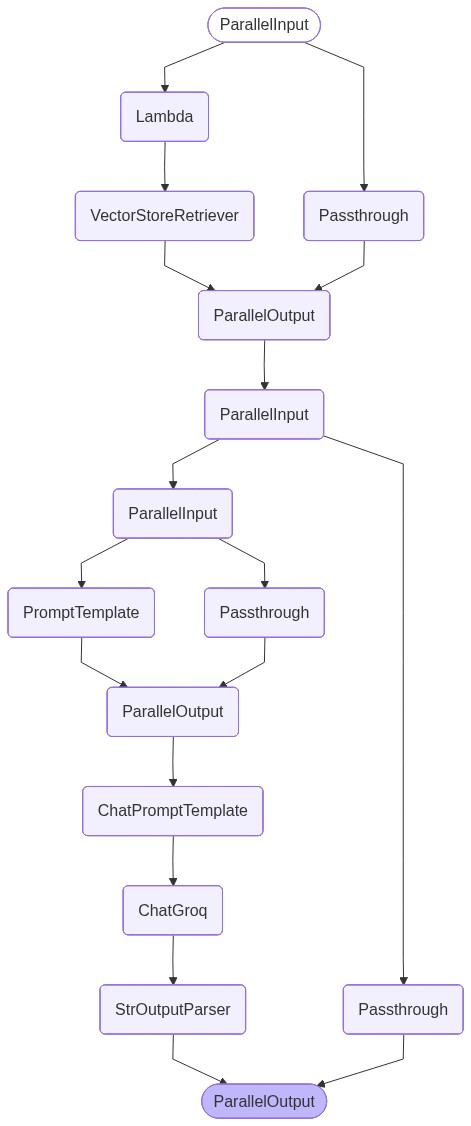

In [ ]:
import os
from IPython.display import Image, display
import grandalf
# ==========================================
# VISUALIZATION IN JUPYTER
# ==========================================

print("1. Text-Based ASCII Pipeline:\n")
print(rag_chain.get_graph().print_ascii())

print("\n2. Graphical Pipeline (Mermaid PNG):\n")
try:
    # This will render a visual flowchart directly in your notebook output
    display(Image(rag_chain.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render PNG (requires internet access to mermaid API): {e}")